In [12]:
import numpy as np
import pickle
from matplotlib import pyplot as plt

In [2]:
def convolution(X: np.ndarray, F: np.ndarray, b: float) -> np.ndarray:
    """
    X (Input): ပုံ သို့မဟုတ် ဒေတာ Matrix
    F (Filter): ပုံစံထုတ်ယူမည့် Pattern Matrix
    b (Bias): ရလဒ်ကို ချိန်ညှိပေးမည့် ကိန်းသေ

    မှတ်ချက်။ ။ 
    - Positive တန်ဖိုးကြီးလျှင် Filter ပါ pattern နှင့် အလွန်တူညီသည်။
    - သုည (Zero) နီးပါးဖြစ်လျှင် Pattern နှင့် မကိုက်ညီပါ။
    - Negative တန်ဖိုးကြီးလျှင် Filter ပါ pattern နှင့် ပြောင်းပြန်ဖြစ်နေသည်။
    """
    X = X.astype(float)
    F = F.astype(float)

    # Output ၏ အတိုင်းအတာကို တွက်ချက်ခြင်း (Stride = 1, Padding = 0)
    H_Out = X.shape[0] - F.shape[0] + 1
    W_Out = X.shape[1] - F.shape[1] + 1

    # Feature Map အတွက် နေရာလွတ် Matrix တစ်ခုတည်ဆောက်ခြင်း
    out = np.empty((H_Out, W_Out))

    # Input ပေါ်တွင် Filter ကို တစ်ဆင့်ချင်း ရွှေ့လျားကာ တွက်ချက်ခြင်း
    for i in range(H_Out):
        for j in range(W_Out):
            # ပုံ၏ သက်ဆိုင်ရာ အစိတ်အပိုင်း (Window) ကို ဖြတ်ထုတ်ခြင်း
            window = X[i:i+F.shape[0], j:j+F.shape[1]]

            # Convolution (Cross-correlation) တွက်ချက်ခြင်း:
            # Window နှင့် Filter ကို တစ်ခုချင်းမြှောက်ပြီး အားလုံးကို ပေါင်းလိုက်ခြင်း
            conv = np.sum(window * F)   

            # Bias ပေါင်းထည့်ပြီး ရလဒ်ကို Feature Map ထဲသို့ သိမ်းဆည်းခြင်း
            out[i, j] = conv + b

    return out

In [ ]:
dataset = []

with open("../BHDD/data.pkl","rb") as file:
    dataset = pickle.load(file)

trainDataset = dataset["trainDataset"]
testDataset = dataset["testDataset"]

print("Train Size: {} Test Size: {}".format(len(trainDataset), len(testDataset)))

Train Size: 60000 Test Size: 27561


/var/folders/d7/5xjp058538n1_2xf1mtj_bwr0000gn/T/ipykernel_58671/2436158696.py:7: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  dataset = pickle.load(file)


In [4]:
trainX = [list(td["image"].flatten() / 255) for td in trainDataset]

idx = 119
image = np.array(trainX[idx]).reshape(28, 28)

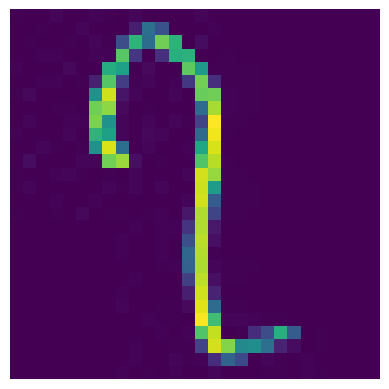

In [5]:
plt.imshow(image, cmap='viridis')
plt.axis('off')
plt.grid(True)
plt.show()

In [ ]:
# Sobel Filter (ဒေါင်လိုက် မျဉ်းကြောင်းများကို ရှာဖွေရန်)
# ဤ Filter သည် ဘယ်ဘက်နှင့် ညာဘက် pixel တန်ဖိုး ကွာခြားချက်ကို ကြည့်ပြီး 
# အနားသတ် (Edges) များကို ဖော်ထုတ်ပေးသည်။
kernel = np.array([
    [-1,  0,  1],
    [-2,  0,  2],
    [-1,  0,  1]
], dtype=float)

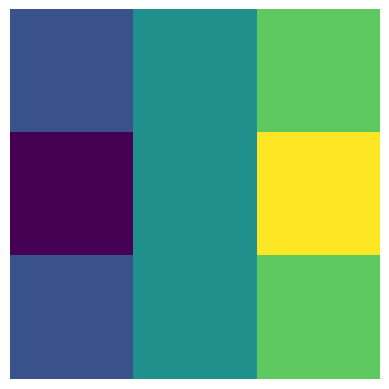

In [7]:
plt.imshow(kernel, cmap='viridis')
plt.axis('off')
plt.grid(True)
plt.show()

Convolution အဆင့် - ရှေ့တွင် ရေးသားခဲ့သော convolution function ကို အသုံးပြုထားသည်

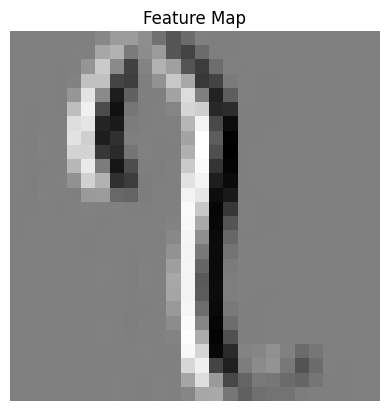

In [ ]:
feature_map = convolution(image, kernel, b=0.0)

plt.imshow(feature_map, cmap='gray')
plt.title("Feature Map")
plt.axis('off')
plt.show()